# Day 24 Deep Learning

But before we get into that, we need to understand a few useful concepts.

In [17]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

### Loss Functions 

Quick introduction I watched: [Here](https://www.youtube.com/watch?v=v_ueBW_5dLg)

This is like a cost function/-loglikelihood/optimisation function/objective function. We are attempting to minimise the offset between what a model predicts and the actual data.

If the difference between the models predictions and the actual data is small, then the loss is small.

So Loss functions allow us to define how well a model is doing mathematically, and if we can calculate the loss, then we can also adjust the model parameters to see if we can reduce it. And we can say that our machine learning model has been sufficiently trained when loss has been minimised below a predefined threshold.

We can have **regression loss functions** and **classification loss functions**.

##### Regression Loss function

This measures errors in predictions involving continuous values, e.g temperature on a given day

We can calculate them using:
- **MSE (mean squared error)**. This is the average of the squared difference between the predicted and true values. And so gives large mistakes a heavy impact on overall loss, strongly punishing outliers.

$$(y-f(x))^2,$$

This is an L2 type loss function where the cost function is the MSE. 

- **MAE (mean absolute error)**. This is the average absolute difference between predicted and true values. It is less sensitive to outliers:

$$|y-f(x)|,$$

This is an L2 loss function.

**Which one do we use?**

If you want to heavily penalise predicted values that are far off from the actual ones, we use MSE. However, if there are more outliers and we don't want the outliers to overly influence the model then we use MAE.

- **Huber Loss** This compromises between the two, behaving like MSE for small errors and MAE for large errors.

##### Classification Loss function

This measures how well the predicted labels match the actual categories.

The main way of doing this is cross entropy loss. It measures how uncertain the models predictions are compared to the true outcomes.

> Entropy is a measure of uncertainty in a system, hence if the model is more uncertain about what the category is, then there is higher entropy

We can also use **Hinge loss**, this is often used in SVMs, and it measures levels of confidence.

It's goal is to make a model correct and confidently correct, by a specified margin. Hence is useful in binary classification tasks where the distinction between right and wrong should be as clear as day.

In classification we usually plot **loss vs** $(y\times f(x))$, where $(y\times f(x))$ corresponds to the known class (one of $\pm 1$) times the predicted value, when $y\times f(x) = 1$ we define there to be zero loss and we got the right answer. 



In [18]:
# Mathematical formulas for various loss functions
def log_loss(raw_model_output):
    return np.log(1+np.exp(-raw_model_output))

def hinge_loss(raw_model_output):
    return np.maximum(0,1-raw_model_output)
 
def l2(raw_model_output):
    return (raw_model_output-1)**2  

def l1(raw_model_output):
    return np.abs(raw_model_output-1)  
 
def zero_one(raw_model_output):
    return np.where(raw_model_output < 0, 1, 0)   

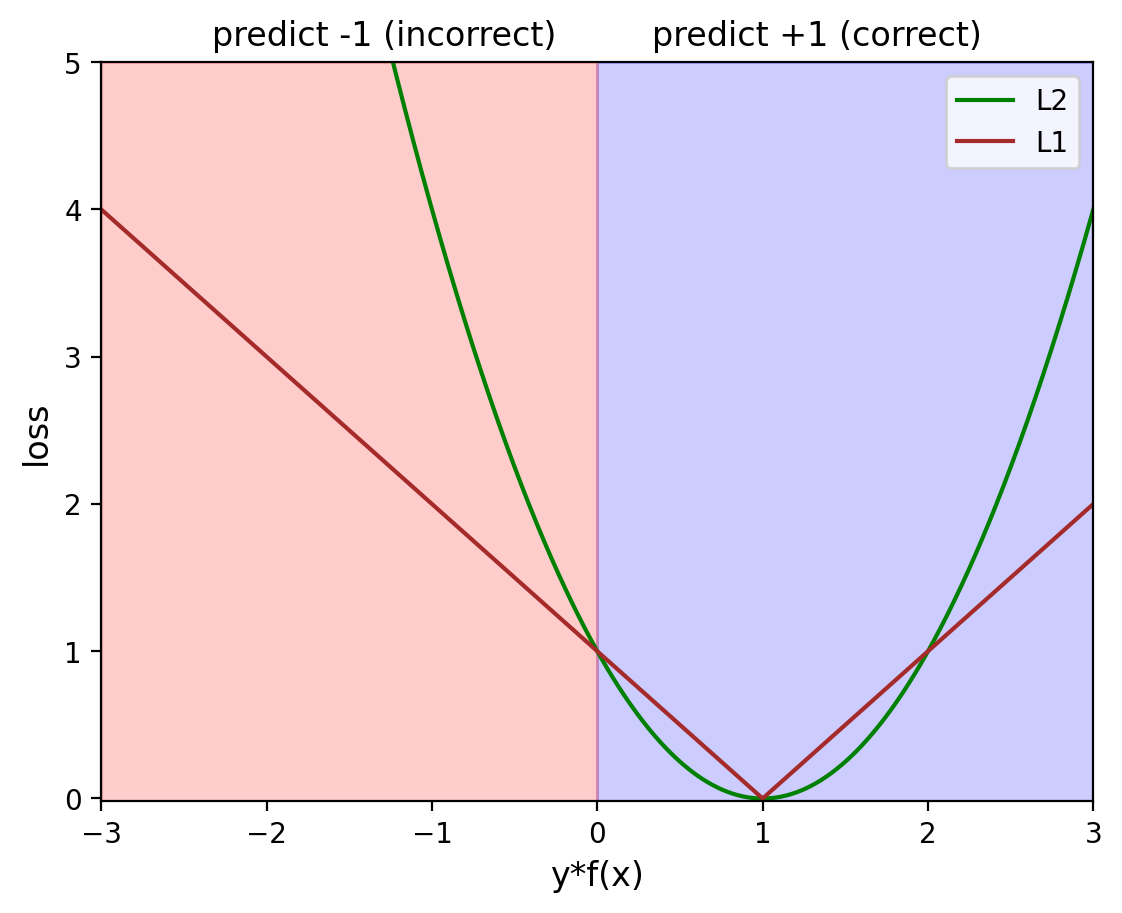

In [19]:
# Create a grid of values and plot
grid = np.linspace(-3,3,1000)
plt.plot(grid, l2(grid), "g", label='L2')
plt.plot(grid, l1(grid), "brown", label='L1')

plt.fill_between([0,3], y1=-0.02, y2=5,
                 color="b", alpha=0.2)
plt.fill_between([-3,0], y1=-0.02, y2=5,
                 color="r", alpha=0.2)
plt.xlim([-3,3])
plt.ylim([-0.02,5])
plt.xlabel("y*f(x)", fontsize=12)
plt.ylabel("loss", fontsize=12)
plt.title("predict -1 (incorrect)         predict +1 (correct)", fontsize=12)
plt.legend()

plt.show()

We can see that when $y*f(x)\le1$, it is pretty reasonable as the loss decreases, however, after 1 it increases again even though we are more confident than before and the class should be 1. So we need something that makes sense:

There are a few we can look at that are plotted below:

1. Zero-One Loss shown in **black**. It is 1 for $yf(x)<0$ and 0 for $yf(x)>0$. The total zero-one loss over a datset represents the exact count of misclassified samples.

$$L_{0-1}(y, f(x)) = \begin{cases} 1 & \text{if } y \cdot f(x) < 0 \\ 0 & \text{if } y \cdot f(x) \geq 0 \end{cases}
$$
This is quite hard to minimise this due to the gradient being 0 everywhere apart from at $$yf(x) = 0$$ where it is undefined.

2. Hinge loss, plotted in orange, looks like:

$${\rm max}(0,1-y*f(x)),$$

There is no contribution to the loss of values $\geq 1$, but there is linearly increasing loss for small values. Hence it penalises wrong predictions and also correct predictions with low confidence.

3. Logistic Loss is shown in blue, and it's also called the cross entropy loss. It is quite smooth and has slightly less and less penalty for more and more confident +1 predictions. Hence it is similar to Hinge but a continuous version


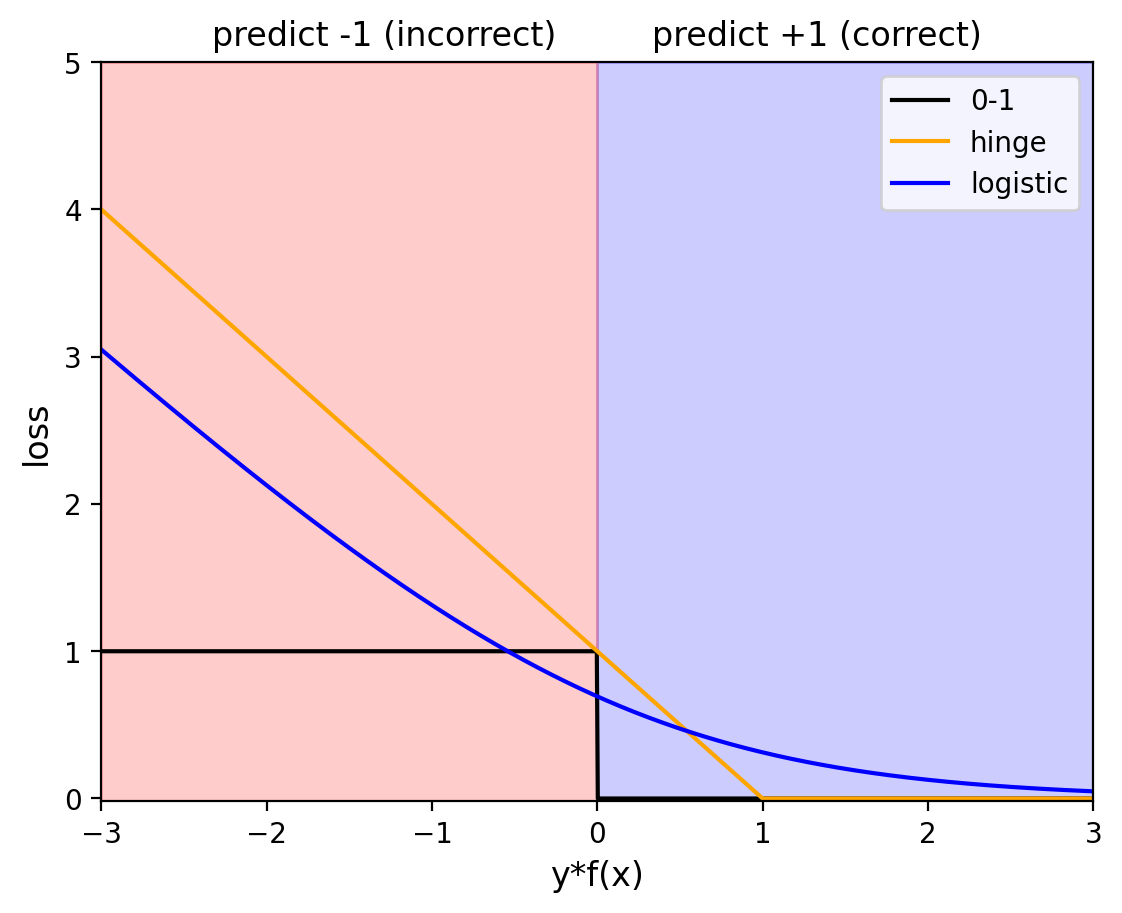

In [20]:
# Create a grid of values and plot
grid = np.linspace(-3,3,1000)

plt.plot(grid, zero_one(grid), "k", label='0-1')
plt.plot(grid, hinge_loss(grid), "orange", label='hinge')
plt.plot(grid, log_loss(grid), "b", label='logistic')

plt.fill_between([0,3], y1=-0.02, y2=5,
                 color="b", alpha=0.2)
plt.fill_between([-3,0], y1=-0.02, y2=5,
                 color="r", alpha=0.2)
plt.xlim([-3,3])
plt.ylim([-0.02,5])
plt.xlabel("y*f(x)",fontsize=12)
plt.ylabel("loss",fontsize=12)
plt.title("predict -1 (incorrect)         predict +1 (correct)",fontsize=12)
plt.legend()

plt.show()

### Gradient Descent

This is a natural continuation from loss functions, and we can use the loss function as input into an algorithm which influences the parameters to minimise loss.

Gradient descent works by calculating the gradient of a loss function with respect to each parameter. Using this gradient, optimisation functions can decide which way to step the algorithm such that we move down the gradient and reduce loss.

We attempt to find the local gradient of the loss function with respect to $\theta$ and go in the steepest direction until the gradient is 0, and hence we have arrived at our destination. 

The mean squared error for a simple linear model is:

$${\rm MSE}({\mathbf \theta}) = \frac{1}{N}(Y - X\theta)^T (Y - X\theta).$$

The partial derivative with respect to the vector of parameters, $\theta$, is:

$$\nabla_{\theta}{\rm MSE}({\mathbf \theta}) = \frac{2}{N}X^T(X\theta - Y).$$

This would give us the uphill direction, but since we wish to go down:

$$\theta^{\rm next step} = \theta - \eta\nabla_{\theta}{\rm MSE}({\mathbf \theta}),$$

Where $eta$ is the learnin rate and the rest are all matrices or vectors.

- We choose the initial values for $\theta$ randomly
- The learning rate controls how large the steps down are
    - If too small, it will take a while to converge
    - If too large you can miss the bottom (and maybe diverge from the solutions)

We want to ensure that we don't end up in a local minimum instead of a global one. Luckily L2 guarantees a single global minimum

Gradient descent can also be used when there are too many training points to fit into the memory at a given time.

In [21]:
np.random.seed(42)

# Run the next 4 cells
# N points randomly drawn from a linear distribution
N = 100
X = 2 * np.random.rand(N, 1)
y = 4 + 3 * X + np.random.randn(N, 1)

# Turn X into a matrix
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each 

# Grid for plotting
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]  # add x0 = 1 to each instance

X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance

In [22]:
eta = 0.1  # learning rate
n_iterations = 100
theta = np.random.randn(2,1)  # random initialization

for iteration in range(n_iterations):
    gradients = 2/N * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [23]:
n_lines=10
color_idx = np.linspace(0, 1, n_lines)

# Helper function
theta_path_bgd = []
def plot_gradient_descent(theta, eta, theta_path=None):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_iterations = 1000
    
    for iteration in range(n_iterations):
        if iteration < 10:
            y_predict = X_new_b.dot(theta)
            plt.plot(X_new, y_predict, color=plt.cm.cool(color_idx[iteration]))
            
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        if theta_path is not None:
            theta_path.append(theta)
            
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta = {}$".format(eta), fontsize=16)

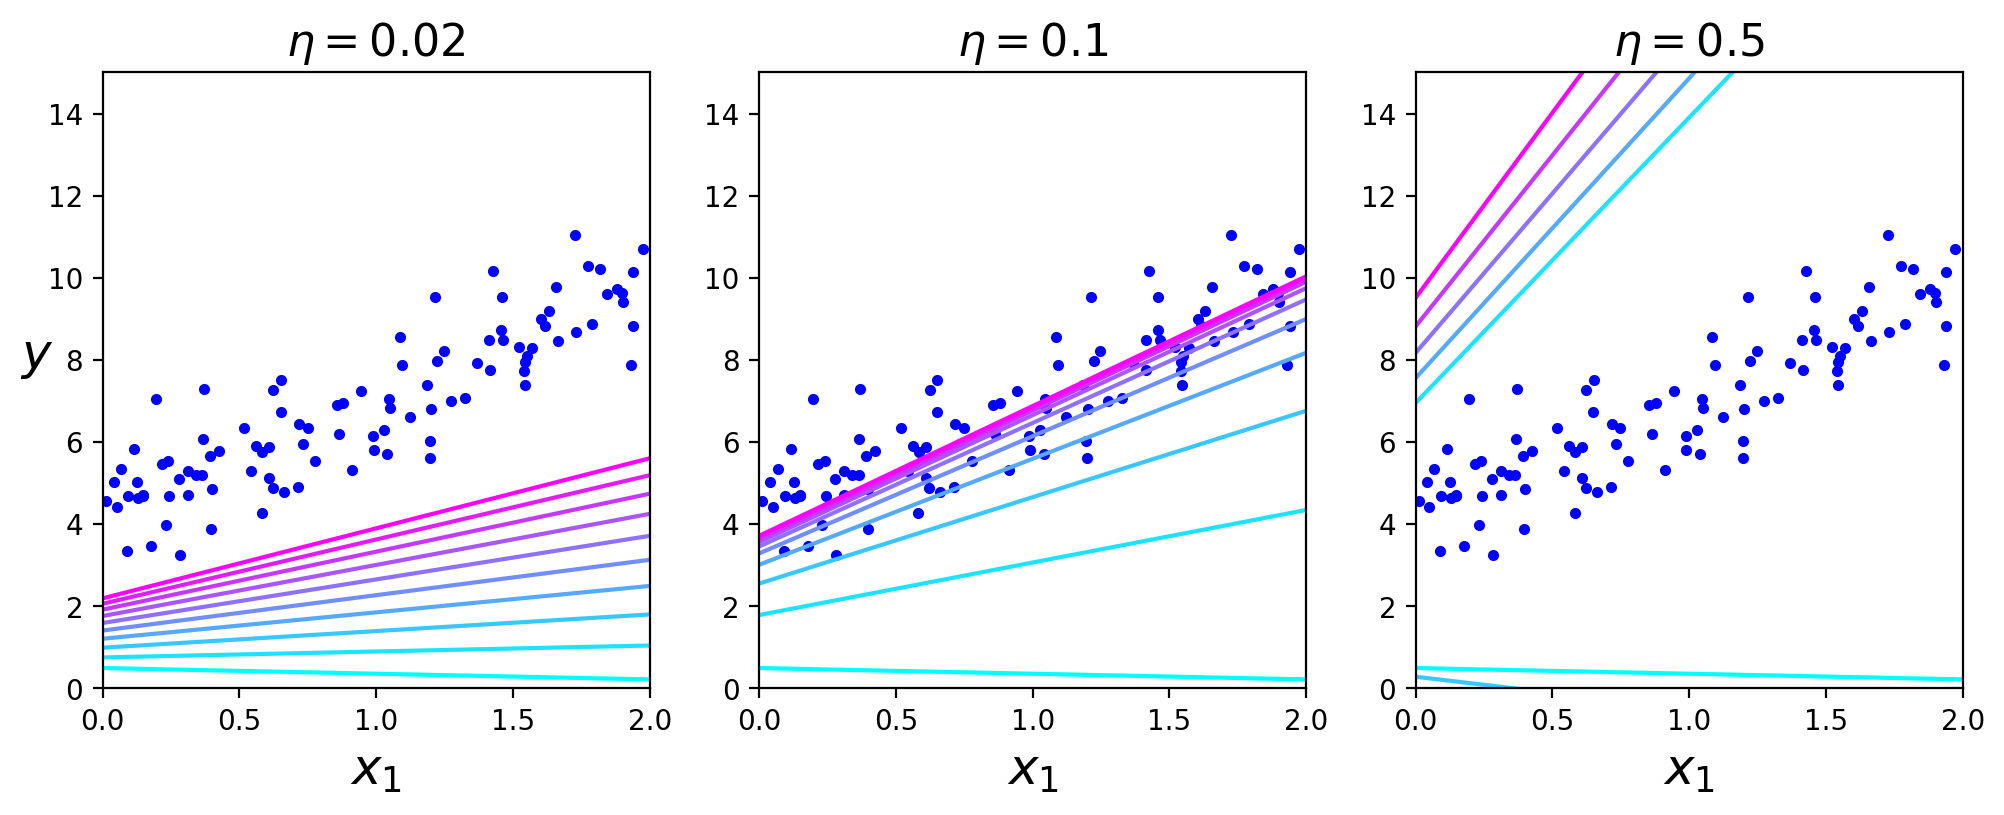

In [24]:
np.random.seed(42)
theta = np.random.randn(2,1)  # random initialization
plt.figure(figsize=(12,4))

plt.subplot(131); plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)

plt.subplot(132); plot_gradient_descent(theta, eta=0.1, 
                                        theta_path=theta_path_bgd)
plt.subplot(133); plot_gradient_descent(theta, eta=0.5)
plt.show()

#### I need to come back and look through this code a little more in depth

### AdaBoost

Something to note as well, look into XGBoost

Adaptive Boosting (Adaboost) specifically learnt from [StatQuest](https://www.youtube.com/watch?v=LsK-xG1cLYA).

(Good to make notes on this a little later, probably as revision)

Let's see this in practice

In [25]:
# Run the next 3 cells
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [26]:
#Helper function for plotting
from matplotlib.colors import ListedColormap
def plot_decision_boundary(clf, X, y, 
                           axes=[-1.5, 2.45, -1, 1.5], 
                           alpha=0.5, contour=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=alpha)
    
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

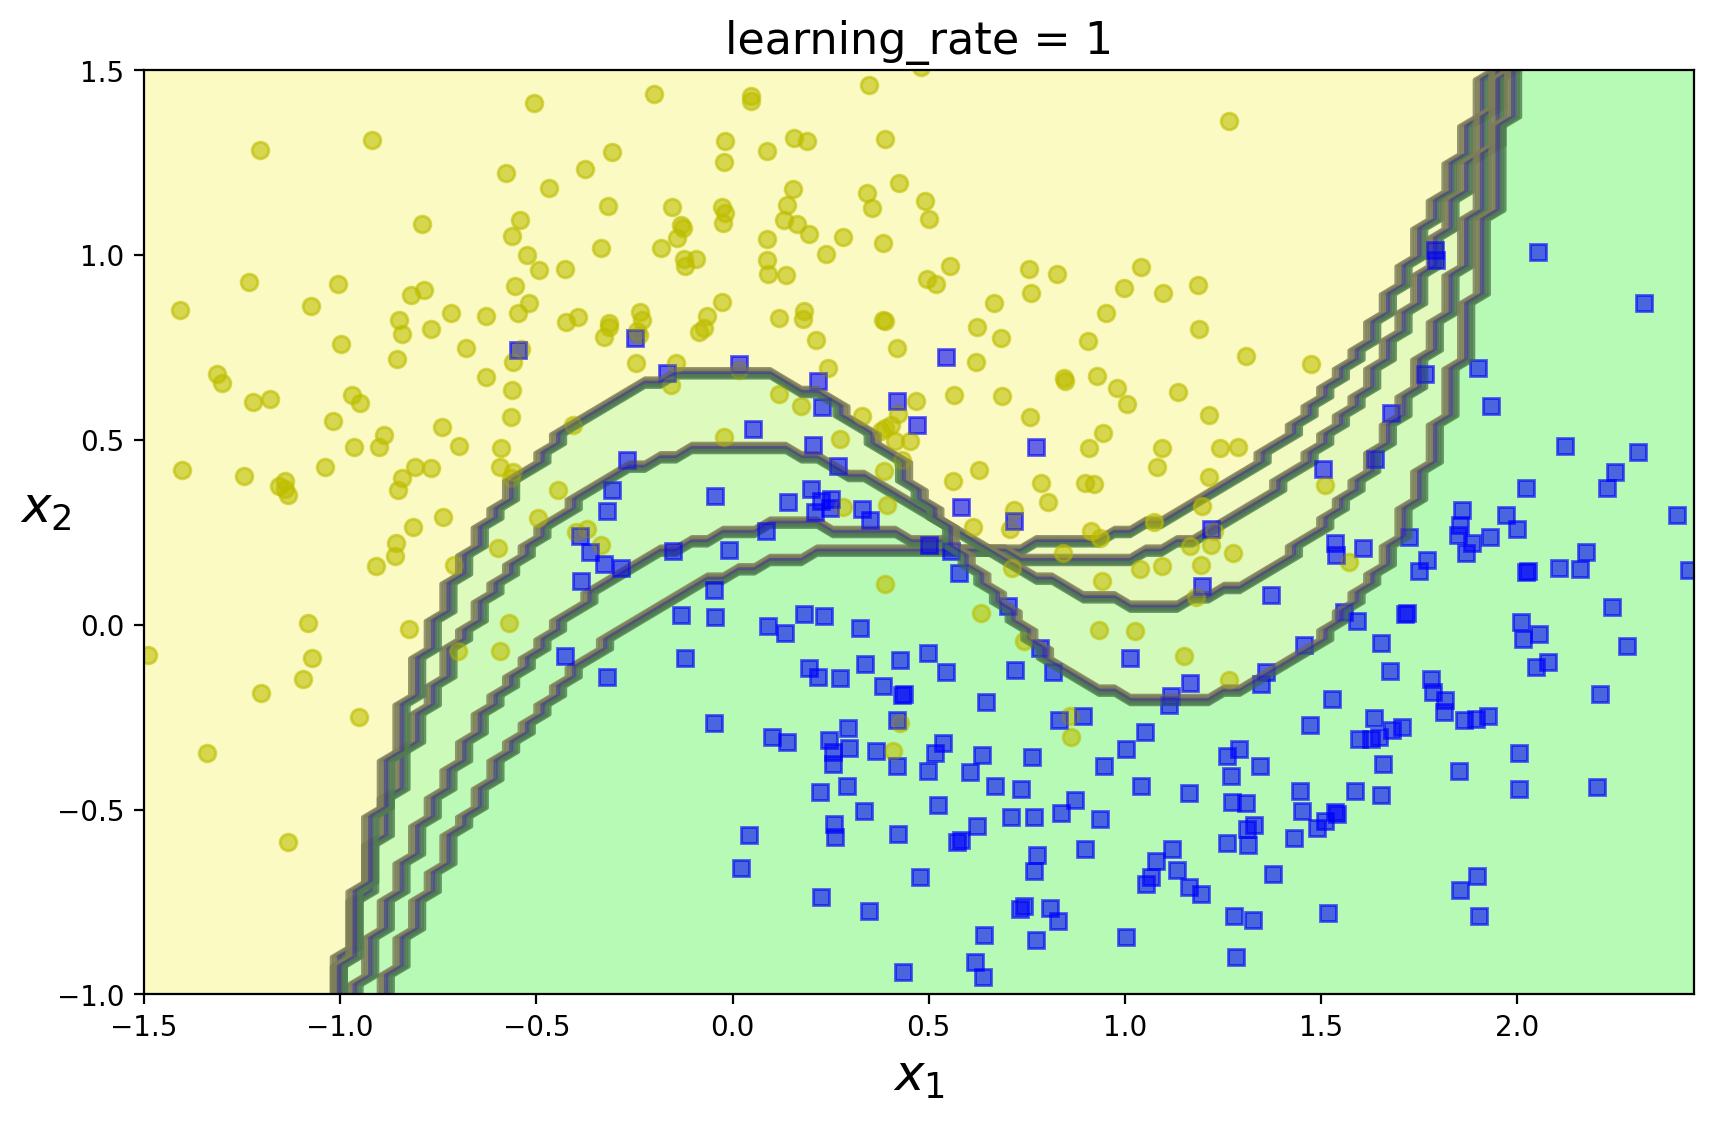

In [27]:
from sklearn.svm import SVC

learning_rate=1
m = len(X_train)

fix, axes = plt.subplots(ncols=1, figsize=(10,6))
sample_weights = np.ones(m)
for i in range(4):
    svm_clf = SVC(kernel="rbf", C=0.05, gamma="scale", random_state=42)
    svm_clf.fit(X_train, y_train, sample_weight=sample_weights)
    
    y_pred = svm_clf.predict(X_train)
    sample_weights[y_pred != y_train] *= (1 + learning_rate)
    
    plot_decision_boundary(svm_clf, X, y, alpha=0.2)
    plt.title("learning_rate = {}".format(learning_rate), fontsize=16)

plt.show()

### Neural Networks

We are looking more so into multi-layer perceptron:

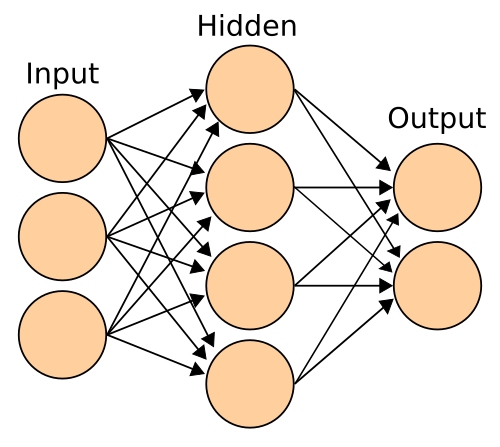

In the image above, 
- The circles on the left represent features of our data, so we have 3 dimensions.
- The circles in the middle represent neurons. They take in information from the input and decide whether or not to "fire" based on some criterion.
- The collective result of the neutrons in the hidden layer produce an output, $y$. Which is represented by the circled on the right.

> The lines connecting the circles represent synapses

The job of the synapses are to take input values, $x_i$ and multiply them by a weight, $w$, and add a bias, $b$. Before passing them to the neuron (hidden layer).

$$z = \sum_i w x_i + b$$

The bias determines the input level at which the neurons fire. We set this to 0 for the sake of simplicity in the maths.

The neurons then sum up the inputs from all of the synapses connected to it and applies an activation function such as a sigmoid activation function:

$$a = \frac{1}{1+e^{-z}}.$$

Notice that $a = f(z)$

**The network learns the weights and biases needed to produce an accurate model of the training ouputs**
> So the model finds good values of $w$ and $b$

We can write the entire hidden layer (what we had z as before) as:

$$Z^{(2)} = X W^{(1)}$$

This excluded the biases. And the superscripts are related to the labels for the layers. Where $W^{(1)}$ means the weights associated with the first set of connections.

**Lets define** $N$ as the number of observations, $D$ as the number of input attributions (features), and $H$ as the number of hidden neurons. Hence, $X: N \times D$ and $W^{(1)}: D \times H$, and so $Z^{2} = XW^{1}$ has dimensions of $N \times H$ 

As we were saying we now have to apply an activation function independently to every entry of $Z^{(2)}$. Hence $A^{(2)} = f(Z^{(2)})$

These values are then the inputs for the next set of synapses, where we multiply the inputs by another set of weights. $W^{(2)}$:

$$Z^{(3)} = A^{(2)} W^{(2)},$$

Where $W^{(2)}$ is an $H\times O$ matrix and $Z^{(3)}$ is an $N\times O$ matrix with $O$ dimensional output. This makes lot's of sense as for N observations we want O outputs per observation.

We apply a final (output layer )activation function:

$$\hat{y} = g(Z^{(3)}),$$

This produces the networks estimate of $y$

**Hence so far we have:**

$$
X
\rightarrow
Z^{(2)}
\rightarrow
A^{(2)}
\rightarrow
Z^{(3)}
\rightarrow
\hat{y}
$$


#### Example

IF we have $N = 100$ people and measure 3 quantities for each; shoe size, belt size, hat size. And we want to predict two quantities; height and weight.

The input matrix has $X: 100 \times 3$. Each column corresponds to the 3 input measurements and the row corresponds to a single person. Hence, $x_{12}$ classifies the 1st person and the 2nd input.

$$
X=
\begin{pmatrix}
x_{11} & x_{12} & x_{13}\\
x_{21} & x_{22} & x_{23}\\
\vdots & \vdots & \vdots\\
x_{100,1} & x_{100,2} & x_{100,3}
\end{pmatrix}
$$

If we want 5 neurons in the hidden layer, then $W^{(1)}: 3 \times 5$ so $Z^{(2)} = XW^{(1)}$ has dimensions of $(100\times3)(3\times5)=100\times5$.

Since we need two outputs, $W^{(2)}:5\times2$, and so $Z^{(3)} = A^{(2)}W^{(2)}$ has dimensions $(100\times5)(5\times2)=100\times2$ which is what we want.

**How do we determine their weights?**

We currently have:

$$
\hat y
=
g\left[
f\left(XW^{(1)}\right)W^{(2)}
\right]
$$

We introduce a cost function that measures how different the predictions are from the true outputs. We use the squared error.

$$
J
=
\sum_i
\frac{1}{2}
\left(y_i-\hat y_i\right)^2
$$

So essentially training the neural network means to minimise this loss, but this may contain many parameters so brute force is impossible.

### Backpropagation

We can calculate the gradient of the cost with respect to the weights, working backwards through the network. Then we use the gradients to update the weight and biases:

$$
J=
\sum_i\frac12
\left[
y_i-
g\left(f(XW^{(1)})W^{(2)}\right)_i
\right]^2
$$

We need the gradient for different layers separately (gradient descent):

$$
\frac{\partial J}{\partial W^{(1)}},
\qquad
\frac{\partial J}{\partial W^{(2)}}
$$

This explains how sensitive the loss is to each weight and which direction they should move to decrease the loss. And will allow us to backpropagate the error contributions along each synapse, and change the weights where they most need to be changed.

When we **backpropagate**, we propagate gradient information backwards through the network, from the output layer towards the input layer, allowing us to calculate how each synaptic weight and neuron bias contributed to the loss.

Once we know the downhill direction from the derivative, we update the weights by subtracting a scalar (learning rate) multiplied by the gradient from the current weights. This is gradient descent. Backpropagation efficiently calculates the gradients, while gradient descent uses the gradients to update the weights.

Backpropagation is basically the chain rule from the final step to the first step:

$$
\frac{\partial J}{\partial w_1}
=
\frac{\partial J}{\partial\hat y}
\frac{\partial\hat y}{\partial z_2}
\frac{\partial z_2}{\partial a_1}
\frac{\partial a_1}{\partial z_1}
\frac{\partial z_1}{\partial w_1}
$$

as we know the sequence is:

$$
w
\rightarrow
z_1
\rightarrow
a_1
\rightarrow
z_2
\rightarrow
\hat y
\rightarrow
J
$$

And so we find $\frac{\delta J}{\delta w}$ we are seeing how much of $J$ changes when we change $w$ slightly. But changing $w$ changes $z$, which changes $a$, $\hat{y}$ and $J$. We multiply all of these effects to find the chain rule.

And then applying thbis to gradient descent we get the formula:

$$
w_{\rm new}
=
w_{\rm old}
-
\eta\frac{\partial J}{\partial w}
$$

So to train the neural network what we are doing overall is:

$$
\text{forward pass}
\rightarrow
\text{calculate loss}
\rightarrow
\text{backpropagate gradients}
\rightarrow
\text{update weights}
$$



### Automatic differentiation

For deep learning, we need to calculate many derivatives, we could naively assume, for a small value of $\Delta x$:

$$f'(x) \sim \frac{f(x+ \Delta x) - f(x)}{\Delta x}$$

However, this can be very unstable as for large $\Delta x$ it isnt accurate and if $\Delta x$ is extremely small, then floating point subtraction can suffer numerical precision errors.

This is where **automatic differentiation** comes into play

A computer differentiating $f(x) = sin(x^2)$ can represent the operations as $x\rightarrow x^2\rightarrow\sin(x^2)$. Since it knows the derivative of each elementary operation, it can join them using chain rule to get $\frac{df}{dx} = 2x \cos(x^2) $

There are also **GPUs** that are very useful for AI as they are good at matrix multiplication which we need for deep learning.

**But once the weights and biases are set through training, we have our neural network classifier/regressor.**


Let us look at the california housing example:



In [28]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing.data
y = housing.target

Xtrain, Xtest, ytrain, ytest = train_test_split( # split the data into 25 test, 75 train
    X, y, test_size=0.25, random_state=42
)

Xtrain_scaled = preprocessing.scale(Xtrain)
Xtest_scaled = preprocessing.scale(Xtest)

[(8, 10), (10, 10), (10, 1)]


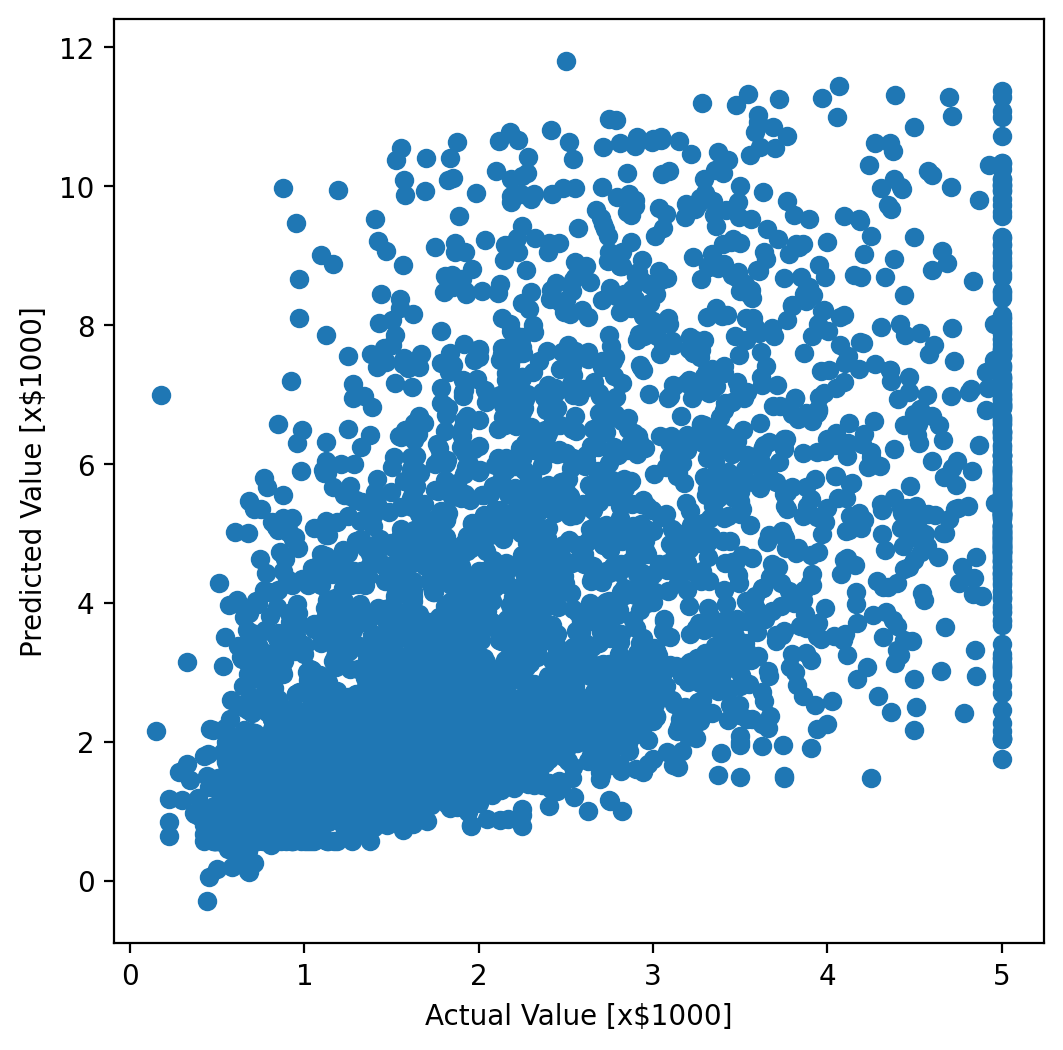

In [29]:
from sklearn.neural_network import MLPRegressor
    
clf = MLPRegressor(solver='lbfgs', alpha=1e-3, 
                   hidden_layer_sizes=(10,10), 
                   random_state=1, max_iter=5000)
clf.fit(Xtrain_scaled, ytrain)

# Look at the weights
print([coef.shape for coef in clf.coefs_]) # This is the weights matrix shape

ypred = clf.predict(Xtest_scaled)

fig = plt.figure(figsize=(6, 6))
plt.scatter(ytest,ypred)
plt.xlabel("Actual Value [x$1000]")
plt.ylabel("Predicted Value [x$1000]")
plt.show()

So we can see we have 8 input features and the first hidden layer has 10 neurons. The second hidden layer also has 10 neurons and we get 1 regression output so it follows:

$$
W^{(1)}:8\times10 \qquad \rightarrow \qquad W^{(2)}:10\times10 \qquad \rightarrow \qquad W^{(3)}:10\times1 
$$

A perfect plot on this predicted vs actual value plot would be a diagonal.



### How many Layers?

"For data that can be represented by a linear model, no layers are required (McCullagh & Nelder 1989). A single layer network can approximate any continuous function. Two layers can represent arbitrary decision boundaries for smooth functions (Lippmann 1987). More layers can represent non-continuous or complex structure within the data."

The reason no layers are needed for linear regression, is that we can connect our input to the output where the synapses are the weights and the output neurons add the constant. So we could start with a single layer, and add more layers to finally use cross validation to see when we are overfitting

### Number of Neurons?

The number of neurons in each layer is a free parameter

- We usually choose between twice the number of input nodes and a number between the number of input and output nodes. 
- If there are lots of hiddne layers, then we call it a deep neural network
- It can be useful to have the same number of neurons in ecah layer so there in only 1 hyperparameter and not one per layer
- Usually we specify many more layers and neurons than we need and perform regularisation. We can do this by stopping the training when the cross validation error is at a minimum, and is called early stopping.

### Activation Functions

This controls how much signal it takes for a neuron to fire, the more signal, the more likely it is to fire.

These are a few different activation functions:


In [30]:
# Mathematical formulas for activation functions
  
def binary(raw_model_output):
    return np.where(raw_model_output < 0, 
                    0, 
                    1)  

def sigmoid(raw_model_output):
    return 1.0 / (1 + np.exp(-raw_model_output))

def ReLU(raw_model_output):
    return np.where(raw_model_output < 0, 
                    0, 
                    raw_model_output)

def LReLU(raw_model_output):
    alpha=0.1
    return np.where(raw_model_output < 0, 
                    alpha*raw_model_output, 
                    raw_model_output)

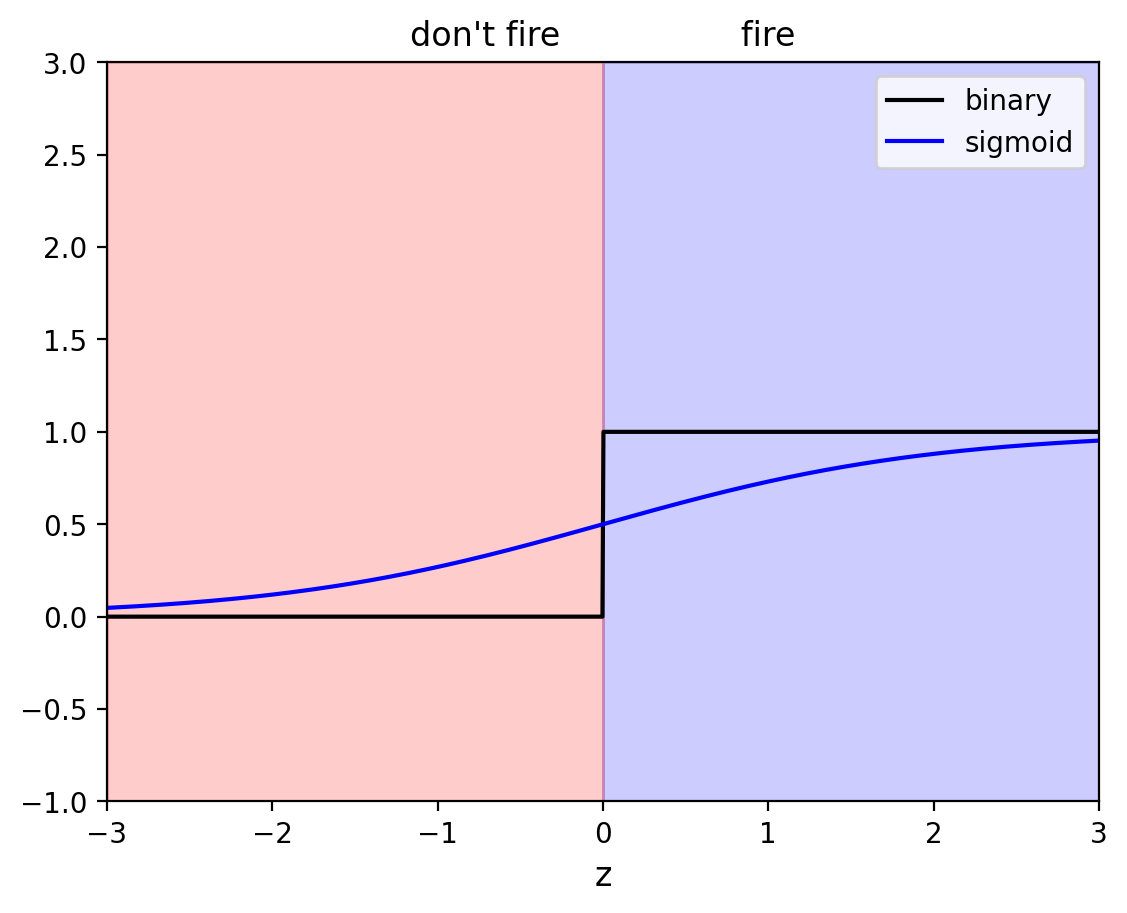

In [31]:
# Create a grid of values and plot
grid = np.linspace(-3,3,1000)
#plt.plot(grid, log_loss(grid), label='logistic')
plt.plot(grid, binary(grid), "k", label='binary')
plt.plot(grid, sigmoid(grid), "b", label='sigmoid')
#plt.plot(grid, ReLU(grid), label='ReLU')
#plt.plot(grid, LReLU(grid), label='LReLU')
#plt.plot(grid, l2(grid), label='L2')
#plt.plot(grid, l1(grid), label='L1')

plt.fill_between([0,3], y1=-1, y2=3, 
                 color="b", alpha=0.2)
plt.fill_between([-3,0], y1=-1, y2=3, 
                 color="r", alpha=0.2)
plt.xlim([-3,3])
plt.ylim([-1,3])
plt.xlabel("z",fontsize=12)
plt.title("don't fire                 fire",fontsize=12)
plt.legend()

plt.show()

We also want nonlinear activation functions which allow neural networks to solve nonlinear problems.



### Vanishing and Exploding gradients

This relates to backpropagation where we had:

$$
\frac{\partial J}{\partial w_1}
=
\frac{\partial J}{\partial\hat y}
\frac{\partial\hat y}{\partial z_L}
\cdots
\frac{\partial a_1}{\partial z_1}
\frac{\partial z_1}{\partial w_1}
$$

Since there are many derivatives multiplied together, if they are typically smaller than 1, then the gradient reaching early layers can become tiny. (vanishing)

If the multiplied terms are repeatedly larger than 1, then the gradient can instead grow a lot. (exploding)

We can use **ReLU** to mitigate this problem, as it follows: ${\rm ReLU}(z)=\max(0,z)$ and its derivative is:

$$
{\rm ReLU}'(z)=
\begin{cases}
0,&z<0\\
1,&z>0
\end{cases}
$$

So that on the positive side, the derivative is 1, so the activation does not continuously shrink the gradients like a sigmoid could. However, since as the derivative is 0 for $z < 0$, the neuron can become stuck and stop learning (dead neuron).

Note that the activation functions can be different in different layers. For example, for regression, one typically doesn't use any activation function in the output layer as including one would restrict the range of possible outputs.

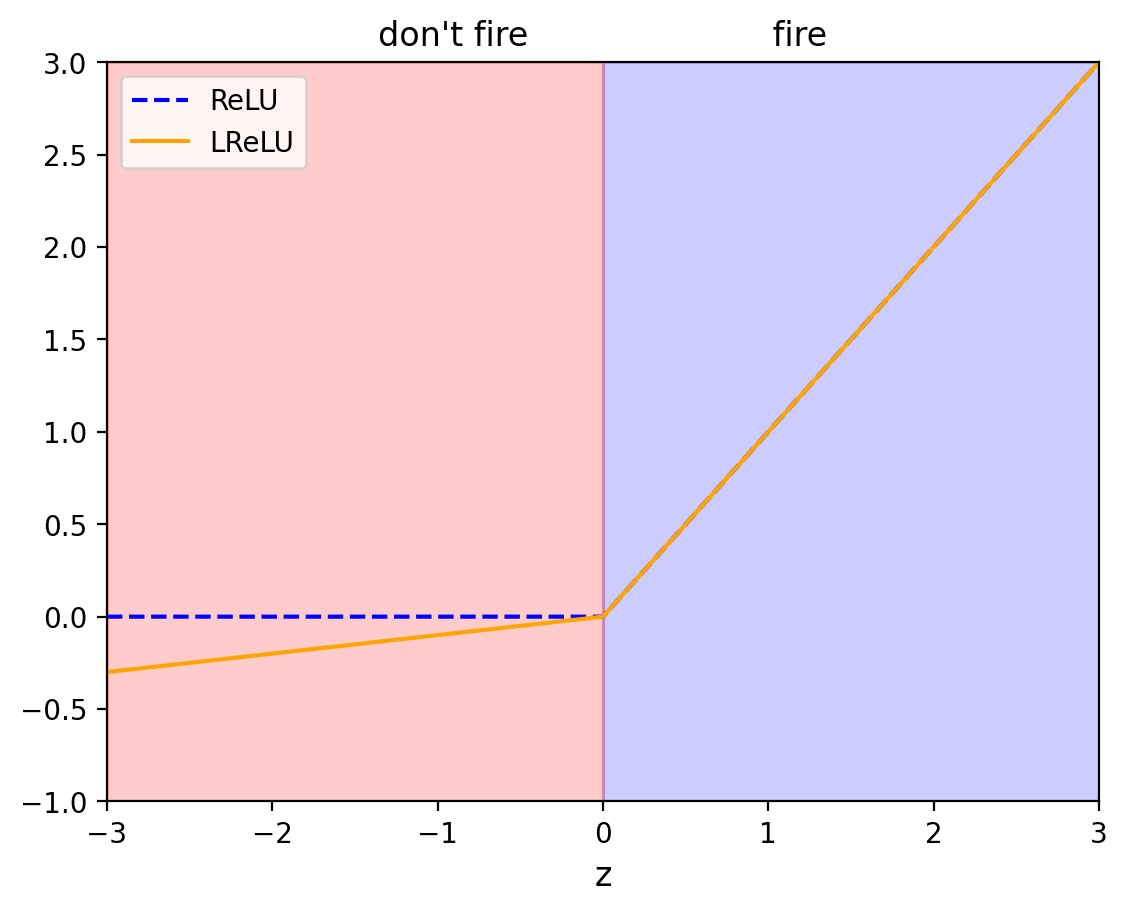

In [32]:
# Create a grid of values and plot
grid = np.linspace(-3,3,1000)
#plt.plot(grid, log_loss(grid), label='logistic')
#plt.plot(grid, binary(grid), "k", label='binary')
#plt.plot(grid, sigmoid(grid), "b", label='sigmoid')
plt.plot(grid, ReLU(grid), "b--", label='ReLU')
plt.plot(grid, LReLU(grid), "orange", label='LReLU')
#plt.plot(grid, l2(grid), label='L2')
#plt.plot(grid, l1(grid), label='L1')

plt.fill_between([0,3], y1=-1, y2=3, 
                 color="b", alpha=0.2)
plt.fill_between([-3,0], y1=-1, y2=3, 
                 color="r", alpha=0.2)
plt.xlim([-3,3])
plt.ylim([-1,3])
plt.xlabel("z",fontsize=12)
plt.title("don't fire                       fire",fontsize=12)
plt.legend()

plt.show()

So usually for activation functions we use:
- A sigmoid for output of classification (with binary cross entropy loss) (**Come back to this**)
- Use ReLU for regression on layers other than the output.

### Regularisation:

We can use standard $L_1$ and $L_2$ regularisation in neural networks:

**For L2**:

$$
J_{\rm total}
=
J_{\rm data}
+
\lambda\sum_jw_j^2
$$

**For L1**

$$
J_{\rm total}
=
J_{\rm data}
+
\lambda\sum_j|w_j|
$$

It has the same purpose, to penalise excessive complexity.

We can also use something called **dropout**:

This causes some neurons to temporarily be dropped out during training, and we set a probability of it happening (10-50%). After training, all neurons are used. This allows a network to not become excessively dependent on 1 neuron.

### Batch normalisation

It is useful to normalise the outputs of hidden layers before applying the activation function, usually you do this by:

$$
\hat z
=
\frac{z-\mu}{\sqrt{\sigma^2+\epsilon}}
$$

### Data augmentation

This is the process of transforming the available data to provide the network with more informative training examples. So instead of just feeding $x$, you can feed $x$ and $x^2$. 

Another way of doing this is to rotate an existing image to give another training sample, this allows the network to focus on the relevant structure rather than accidental properties from the initial sample.

### Fast optimisers

An optimiser decides how to use the gradients calculated from backpropagation in order to update the parameters. (**Probably have more of a look into this**)

### Training, validation and test sets

Deep learning models can have lots of hyperparameters (learning rate, number of layers, neurons per layer, activation choices, batch size, regularisation, etc). So we need 3 different datasets

1. Training set
- This is used to determine the actual model parameters.

2. Validation set
- This is used to evaluate performance, we use this to tune the hyperparameters and obtain the best network

3. Test set
- The overall performance is evaluated on an external test set.